DATA VISUALIZATION

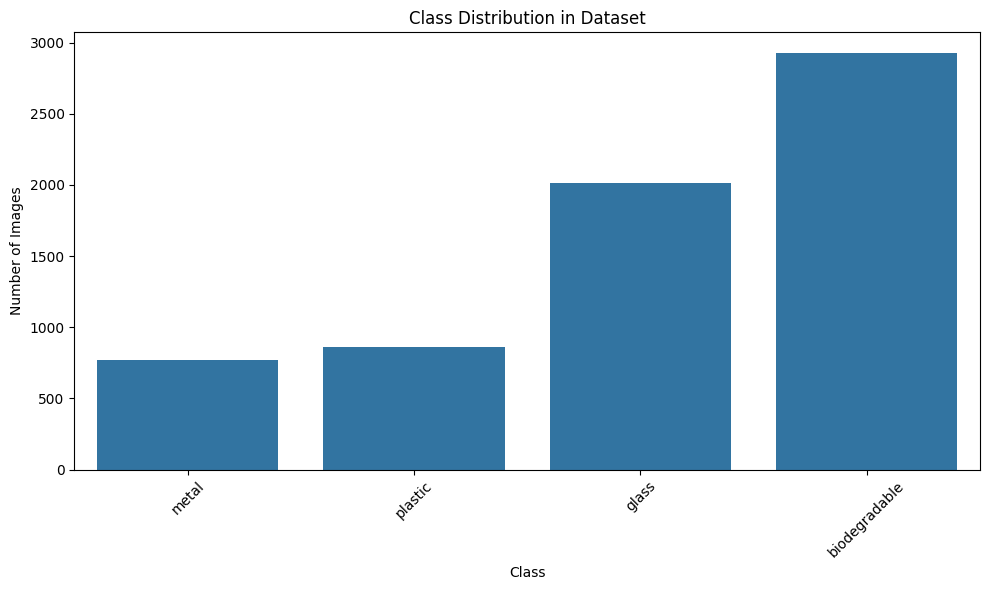

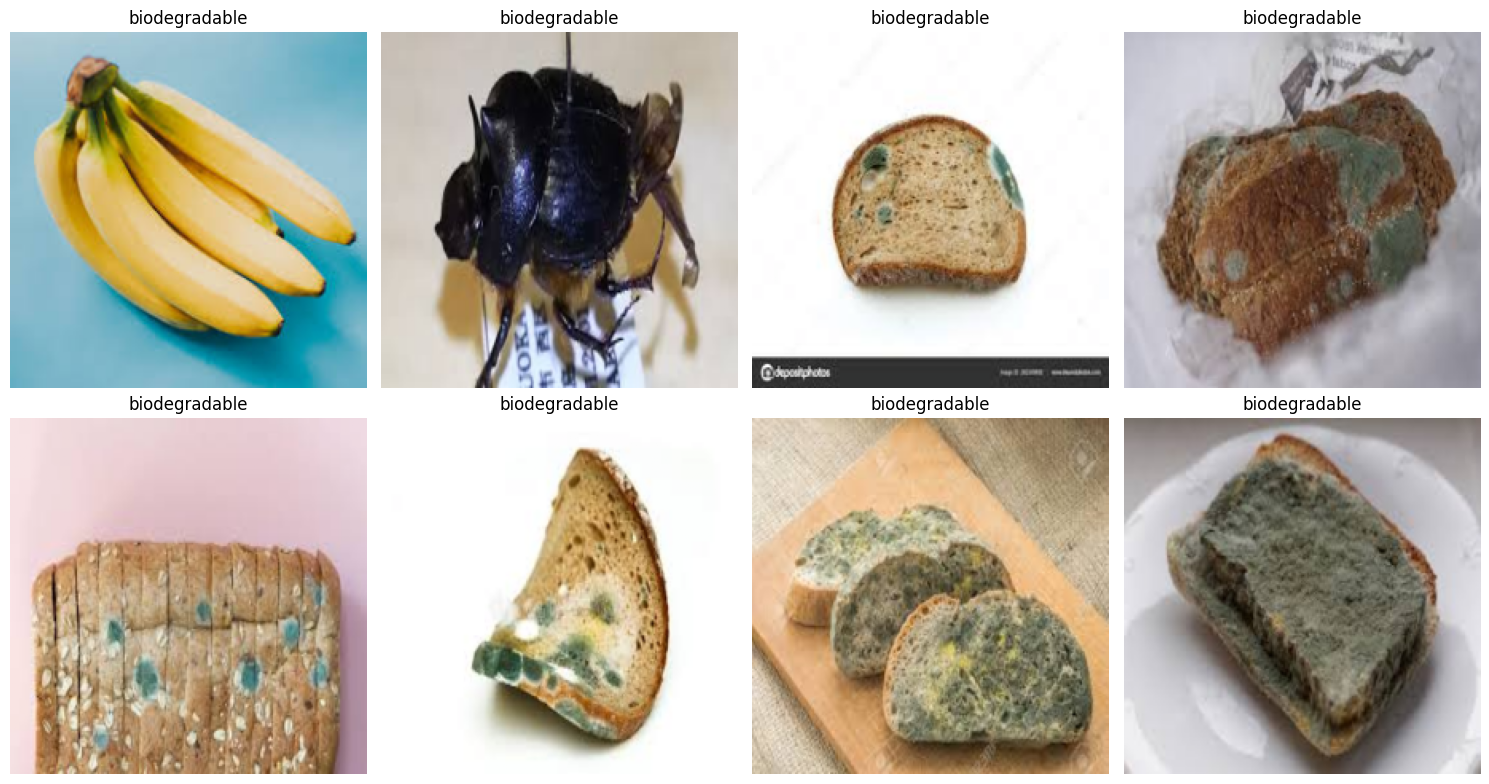

Total images: 6571
Training images: 5256
Validation images: 1315


In [1]:
import os
import torch
import torchvision
from torchvision import transforms
from torch.utils.data import DataLoader, Dataset
from PIL import Image
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
import numpy as np

# Define classes and their groupings
CLASS_GROUPS = {
    'metal': ['metal'],
    'plastic': ['plastic'],
    'glass': ['brown-glass', 'green-glass', 'white-glass'],
    'biodegradable': ['biological', 'paper', 'cardboard']
}

# Create reverse mapping
CLASS_MAPPING = {}
for group, classes in CLASS_GROUPS.items():
    for cls in classes:
        CLASS_MAPPING[cls] = group

class WasteDataset(Dataset):
    def __init__(self, root_dir, transform=None):
        self.root_dir = root_dir
        self.transform = transform
        self.images = []
        self.labels = []
        self.class_to_idx = {group: idx for idx, group in enumerate(CLASS_GROUPS.keys())}
        
        # Collect all images and labels
        for folder in os.listdir(root_dir):
            if folder in CLASS_MAPPING:
                folder_path = os.path.join(root_dir, folder)
                if os.path.isdir(folder_path):
                    for img_name in os.listdir(folder_path):
                        if img_name.lower().endswith(('.png', '.jpg', '.jpeg')):
                            self.images.append(os.path.join(folder_path, img_name))
                            group = CLASS_MAPPING[folder]
                            self.labels.append(self.class_to_idx[group])

    def __len__(self):
        return len(self.images)

    def __getitem__(self, idx):
        img_path = self.images[idx]
        image = Image.open(img_path).convert('RGB')
        label = self.labels[idx]
        
        if self.transform:
            image = self.transform(image)
            
        return image, label

# Data transforms
data_transforms = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

# Create dataset
dataset = WasteDataset('garbage_classification', transform=data_transforms)

# Split dataset
train_idx, val_idx = train_test_split(
    range(len(dataset)), 
    test_size=0.2, 
    stratify=dataset.labels,
    random_state=42
)

# Create train and validation datasets
from torch.utils.data import Subset
train_dataset = Subset(dataset, train_idx)
val_dataset = Subset(dataset, val_idx)

# Create data loaders
train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=32, shuffle=False)

# Visualize class distribution
def plot_class_distribution():
    labels = [dataset.labels[i] for i in range(len(dataset))]
    class_names = list(CLASS_GROUPS.keys())
    
    plt.figure(figsize=(10, 6))
    sns.countplot(x=labels)
    plt.xticks(range(len(class_names)), class_names, rotation=45)
    plt.title('Class Distribution in Dataset')
    plt.xlabel('Class')
    plt.ylabel('Number of Images')
    plt.tight_layout()
    plt.show()

# Display sample images
def show_samples():
    fig, axes = plt.subplots(2, 4, figsize=(15, 8))
    axes = axes.ravel()
    
    for idx in range(8):
        img, label = dataset[idx]
        img = img.permute(1, 2, 0)
        img = img * torch.tensor([0.229, 0.224, 0.225]) + torch.tensor([0.485, 0.456, 0.406])
        img = img.numpy()
        img = np.clip(img, 0, 1)
        
        axes[idx].imshow(img)
        axes[idx].set_title(list(CLASS_GROUPS.keys())[label])
        axes[idx].axis('off')
    
    plt.tight_layout()
    plt.show()

# Run visualizations
plot_class_distribution()
show_samples()

print(f"Total images: {len(dataset)}")
print(f"Training images: {len(train_dataset)}")
print(f"Validation images: {len(val_dataset)}")

MODEL DESIGN AND TRAINING

In [2]:
import torch
import torch.nn as nn
import torch.optim as optim
from torchvision.models import mobilenet_v3_small, MobileNet_V3_Small_Weights

class WasteClassifier(nn.Module):
    def __init__(self, num_classes=4):
        super(WasteClassifier, self).__init__()
        self.model = mobilenet_v3_small(weights=MobileNet_V3_Small_Weights.DEFAULT)
        self.model.classifier[-1] = nn.Linear(self.model.classifier[-1].in_features, num_classes)
        
    def forward(self, x):
        return self.model(x)

# Training function
def train_model(model, train_loader, val_loader, criterion, optimizer, num_epochs=10, device='cuda'):
    model = model.to(device)
    best_val_acc = 0.0
    
    for epoch in range(num_epochs):
        # Training phase
        model.train()
        running_loss = 0.0
        correct = 0
        total = 0
        
        for inputs, labels in train_loader:
            inputs, labels = inputs.to(device), labels.to(device)
            
            optimizer.zero_grad()
            outputs = model(inputs)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()
            
            running_loss += loss.item()
            _, predicted = outputs.max(1)
            total += labels.size(0)
            correct += predicted.eq(labels).sum().item()
        
        train_acc = 100. * correct / total
        
        # Validation phase
        model.eval()
        val_correct = 0
        val_total = 0
        
        with torch.no_grad():
            for inputs, labels in val_loader:
                inputs, labels = inputs.to(device), labels.to(device)
                outputs = model(inputs)
                _, predicted = outputs.max(1)
                val_total += labels.size(0)
                val_correct += predicted.eq(labels).sum().item()
        
        val_acc = 100. * val_correct / val_total
        
        print(f'Epoch {epoch+1}/{num_epochs}:')
        print(f'Training Loss: {running_loss/len(train_loader):.3f}')
        print(f'Training Accuracy: {train_acc:.2f}%')
        print(f'Validation Accuracy: {val_acc:.2f}%')
        
        if val_acc > best_val_acc:
            best_val_acc = val_acc
            torch.save(model.state_dict(), 'best_model.pth')
    
    return model

# Initialize model and training parameters
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
model = WasteClassifier(num_classes=4)
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)

# Train the model
trained_model = train_model(
    model, 
    train_loader, 
    val_loader,
    criterion, 
    optimizer,
    num_epochs=10,
    device=device
)

Epoch 1/10:
Training Loss: 0.419
Training Accuracy: 84.59%
Validation Accuracy: 87.83%
Epoch 2/10:
Training Loss: 0.224
Training Accuracy: 91.67%
Validation Accuracy: 90.95%
Epoch 3/10:
Training Loss: 0.136
Training Accuracy: 94.86%
Validation Accuracy: 91.56%
Epoch 4/10:
Training Loss: 0.104
Training Accuracy: 96.50%
Validation Accuracy: 89.35%
Epoch 5/10:
Training Loss: 0.110
Training Accuracy: 96.29%
Validation Accuracy: 83.27%
Epoch 6/10:
Training Loss: 0.091
Training Accuracy: 97.13%
Validation Accuracy: 91.03%
Epoch 7/10:
Training Loss: 0.072
Training Accuracy: 97.55%
Validation Accuracy: 85.93%
Epoch 8/10:
Training Loss: 0.072
Training Accuracy: 97.49%
Validation Accuracy: 89.43%
Epoch 9/10:
Training Loss: 0.055
Training Accuracy: 98.15%
Validation Accuracy: 91.63%
Epoch 10/10:
Training Loss: 0.075
Training Accuracy: 97.39%
Validation Accuracy: 87.60%


In [4]:
import os
import torch
import torch.nn as nn
import torch.optim as optim
import torchvision
from torchvision import transforms
from torch.utils.data import DataLoader, Dataset, Subset
from PIL import Image
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
import numpy as np
from tqdm.auto import tqdm
from torch.optim.lr_scheduler import OneCycleLR

# Enhanced data augmentation using only torchvision
train_transforms = transforms.Compose([
    transforms.RandomResizedCrop(224, scale=(0.8, 1.0)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomVerticalFlip(),
    transforms.RandomApply([
        transforms.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.2, hue=0.1),
    ], p=0.5),
    transforms.RandomApply([
        transforms.GaussianBlur(3)
    ], p=0.2),
    transforms.RandomRotation(15),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

val_transforms = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

def train_model_with_progress(model, train_loader, val_loader, criterion, optimizer, scheduler, num_epochs=20, device='cuda'):
    model = model.to(device)
    best_val_acc = 0.0
    patience = 5
    patience_counter = 0
    
    # Main training loop with progress bar
    epoch_bar = tqdm(range(num_epochs), desc='Training Progress')
    
    for epoch in epoch_bar:
        # Training phase
        model.train()
        running_loss = 0.0
        correct = 0
        total = 0
        
        # Batch progress bar
        batch_bar = tqdm(train_loader, desc=f'Epoch {epoch+1}', leave=False)
        
        for inputs, labels in batch_bar:
            inputs, labels = inputs.to(device), labels.to(device)
            
            optimizer.zero_grad()
            outputs = model(inputs)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()
            
            if scheduler is not None:
                scheduler.step()
            
            running_loss += loss.item()
            _, predicted = outputs.max(1)
            total += labels.size(0)
            correct += predicted.eq(labels).sum().item()
            
            # Update batch progress bar
            train_acc = 100. * correct / total
            batch_bar.set_postfix({
                'loss': f'{loss.item():.3f}',
                'acc': f'{train_acc:.2f}%'
            })
        
        # Validation phase
        model.eval()
        val_loss = 0.0
        val_correct = 0
        val_total = 0
        
        with torch.no_grad():
            for inputs, labels in val_loader:
                inputs, labels = inputs.to(device), labels.to(device)
                outputs = model(inputs)
                loss = criterion(outputs, labels)
                val_loss += loss.item()
                _, predicted = outputs.max(1)
                val_total += labels.size(0)
                val_correct += predicted.eq(labels).sum().item()
        
        val_acc = 100. * val_correct / val_total
        
        # Update epoch progress bar
        epoch_bar.set_postfix({
            'train_loss': f'{running_loss/len(train_loader):.3f}',
            'train_acc': f'{train_acc:.2f}%',
            'val_acc': f'{val_acc:.2f}%'
        })
        
        # Early stopping check
        if val_acc > best_val_acc:
            best_val_acc = val_acc
            torch.save({
                'epoch': epoch,
                'model_state_dict': model.state_dict(),
                'optimizer_state_dict': optimizer.state_dict(),
                'val_acc': val_acc,
            }, 'best_model.pth')
            patience_counter = 0
        else:
            patience_counter += 1
            if patience_counter >= patience:
                print(f'\nEarly stopping triggered after {epoch+1} epochs')
                break
    
    return model

# Initialize model and training parameters
print("Initializing model and parameters...")
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
model = WasteClassifier(num_classes=4)
criterion = nn.CrossEntropyLoss(label_smoothing=0.1)
optimizer = optim.AdamW(model.parameters(), lr=1e-3, weight_decay=1e-5)

# Calculate steps per epoch for the scheduler
steps_per_epoch = len(train_loader)
scheduler = OneCycleLR(
    optimizer,
    max_lr=1e-3,
    epochs=20,
    steps_per_epoch=steps_per_epoch,
    pct_start=0.3,
    anneal_strategy='cos'
)

print(f"\nUsing device: {device}")
print(f"Number of training batches per epoch: {len(train_loader)}")
print(f"Number of validation batches: {len(val_loader)}")
print("\nStarting training...\n")

# Train the model
trained_model = train_model_with_progress(
    model, 
    train_loader, 
    val_loader,
    criterion, 
    optimizer,
    scheduler,
    num_epochs=20,
    device=device
)

print("\nTraining completed!")
print(f"Best model saved as 'best_model.pth'")

Initializing model and parameters...

Using device: cuda
Number of training batches per epoch: 165
Number of validation batches: 42

Starting training...



Training Progress:   0%|          | 0/20 [00:00<?, ?it/s]

Epoch 1:   0%|          | 0/165 [00:00<?, ?it/s]

Epoch 2:   0%|          | 0/165 [00:00<?, ?it/s]

Epoch 3:   0%|          | 0/165 [00:00<?, ?it/s]

...

Epoch 17:   0%|          | 0/165 [00:00<?, ?it/s]

Epoch 18:   0%|          | 0/165 [00:00<?, ?it/s]

Epoch 19:   0%|          | 0/165 [00:00<?, ?it/s]

Epoch 20:   0%|          | 0/165 [00:00<?, ?it/s]


Training completed!
Best model saved as 'best_model.pth'


Testing multiple images...

Testing image: pet_test.jpg


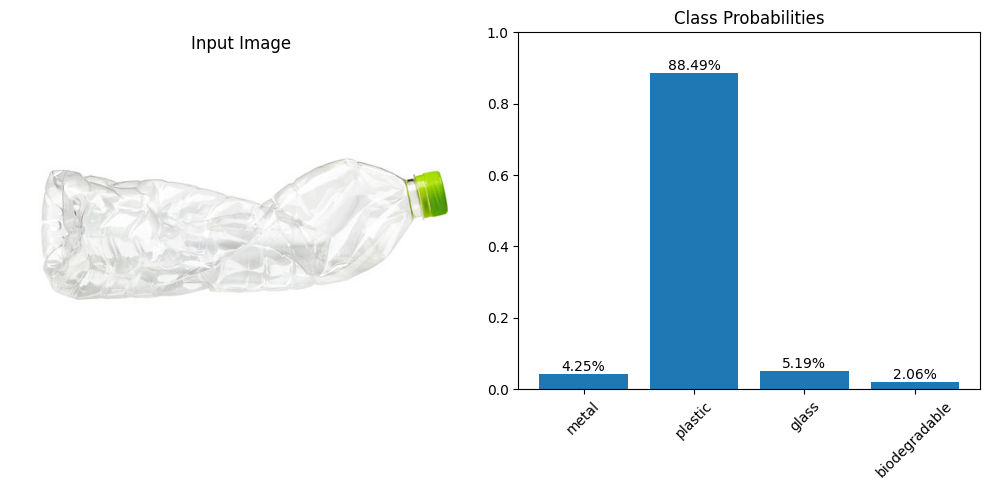


Predicted class: plastic
Confidence: 88.49%

All class probabilities:
metal: 4.25%
plastic: 88.49%
glass: 5.19%
biodegradable: 2.06%
--------------------------------------------------

Testing image: plastic_test.jpg


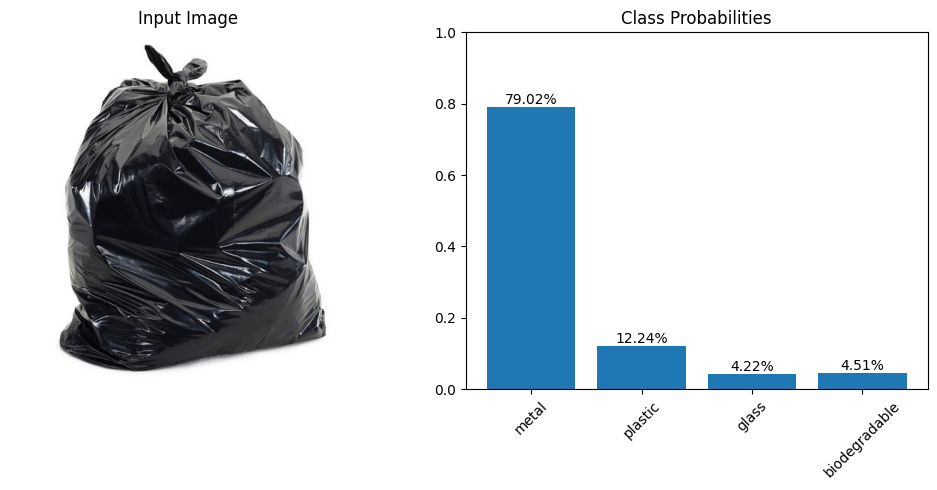


Predicted class: metal
Confidence: 79.02%

All class probabilities:
metal: 79.02%
plastic: 12.24%
glass: 4.22%
biodegradable: 4.51%
--------------------------------------------------

Testing image: metal_test.jpg


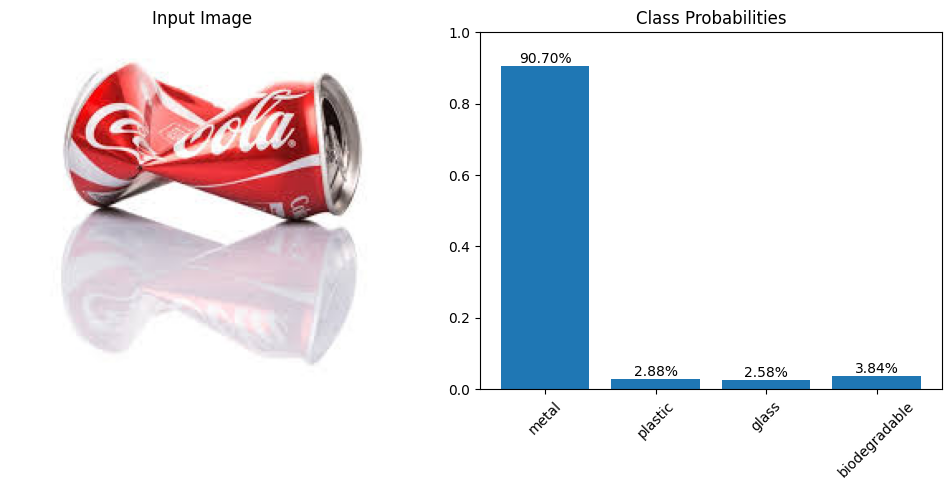


Predicted class: metal
Confidence: 90.70%

All class probabilities:
metal: 90.70%
plastic: 2.88%
glass: 2.58%
biodegradable: 3.84%
--------------------------------------------------


In [8]:
def predict_image(model, image_path):
    # Load and preprocess the image
    image = Image.open(image_path).convert('RGB')
    
    # Apply the same transforms as validation
    transform = transforms.Compose([
        transforms.Resize((224, 224)),
        transforms.ToTensor(),
        transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
    ])
    
    # Preprocess image
    image_tensor = transform(image)
    image_tensor = image_tensor.unsqueeze(0)  # Add batch dimension
    
    # Move to device and set model to eval mode
    model.eval()
    image_tensor = image_tensor.to(device)
    
    # Get prediction
    with torch.no_grad():
        outputs = model(image_tensor)
        _, predicted = outputs.max(1)
        probabilities = torch.nn.functional.softmax(outputs, dim=1)
    
    # Get class names and probabilities
    class_names = list(CLASS_GROUPS.keys())
    class_probs = probabilities[0].cpu().numpy()
    
    # Plot the image with predictions
    plt.figure(figsize=(10, 5))
    
    # Original image
    plt.subplot(1, 2, 1)
    plt.imshow(image)
    plt.title('Input Image')
    plt.axis('off')
    
    # Probability bar plot
    plt.subplot(1, 2, 2)
    bars = plt.bar(class_names, class_probs)
    plt.title('Class Probabilities')
    plt.xticks(rotation=45)
    plt.ylim(0, 1)
    
    # Add probability values on top of bars
    for bar in bars:
        height = bar.get_height()
        plt.text(bar.get_x() + bar.get_width()/2., height,
                f'{height:.2%}',
                ha='center', va='bottom')
    
    plt.tight_layout()
    plt.show()
    
    # Print prediction
    predicted_class = class_names[predicted.item()]
    confidence = class_probs[predicted.item()]
    print(f'\nPredicted class: {predicted_class}')
    print(f'Confidence: {confidence:.2%}')
    
    # Print all class probabilities
    print('\nAll class probabilities:')
    for class_name, prob in zip(class_names, class_probs):
        print(f'{class_name}: {prob:.2%}')

# Example usage
# Replace 'path_to_your_image.jpg' with the path to your test image
# predict_image(model, 'pet_test.jpg')

# You can also create a simple test function for multiple images:
def test_multiple_images(model, image_paths):
    print("Testing multiple images...")
    for path in image_paths:
        print(f"\nTesting image: {path}")
        predict_image(model, path)
        print("-" * 50)

# Example usage for multiple images:

test_images = [
    'pet_test.jpg',
    'plastic_test.jpg',
    'metal_test.jpg'
]
test_multiple_images(model, test_images)
